## MLE and MAP
MLE(Maximum Likelihood Estimation): 最大似然估计

MAP(Maximum a Posterior Probability Estimation): 最大后验估计 

他们都是来预测这个$\theta$的

## MLE
MLE通常分为两个步骤
- 首先要进行明确的建模假设
- 之后设置该分布的参数，使得观察到的数据尽可能拟合

但是MLE对于数据量较少的时候会过拟合，所以如果数据量比较少的时候我们需要先验信念来修正它

所以先验+MLE=MAP
公式$$\hat{\theta}_{\text{MLE}} = \arg\max_{\theta} P(D; \theta)$$

找一个参数 θ，让 “当前看到的数据” 出现的概率最大

## MAP
从公式上看，MLE和MAP的目标函数最大值不一样
$$
\hat{\theta}_{\text{MAP}} = \arg\max_{\theta} P(\theta \mid D)
$$
根据贝叶斯公式
$$
P(\theta|D)=\frac{P(D|\theta)P(\theta)}{P(D)}
$$
其中MAP不同的是将$P(\theta)$当作一种分布函数（pdf中说其是一种随机变量）

然后就是$P(\theta|D)$是跟上面MLE公式类似的，就是这个是似然的部分,P(D)可以丢到，因为其与$P(\theta)$无关

之后就是常见的$P(\theta)$函数分布，我们很喜欢选择的是Beta函数分布
$$P(\theta) = \frac{\theta^{\alpha-1}(1-\theta)^{\beta-1}}{B(\alpha, \beta)}$$
其中$B(\alpha, \beta) = \frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha+\beta)}$是归一化常数
简单回忆一下gamma函数（右边）：
- 当n是正整数的时候：$\Gamma(n) = (n-1)!$
- $\Gamma(\sqrt{0.5})=\sqrt\pi$

为什么这个分布合适：

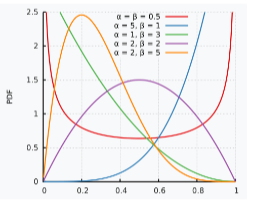

看图吧，就是$\alpha$和$\beta$取不同值的时候其分布如图上

要是抛硬币的话自然想到用紫色这个线

最后就是求最值，直接给公式
$$
\hat{\theta}_{\text{MAP}} = \arg\max_{\theta} P(\theta \mid D)=\frac{n_H+\alpha-1}{n_H+n_T+\alpha+\beta-2}
$$
- 公式自己推导，直接取对数求导，导数等于0

最后就是最全面的贝叶斯法预测，其中上面的MLE和MAP都是找出能让目标概率函数最大的$\theta$,而贝叶斯法预测则是将所有在D结果下所有$\theta$做加权平均
$$
P(Y|D)=\int_{\theta}P(Y|\theta)P(\theta|D)d\theta
$$

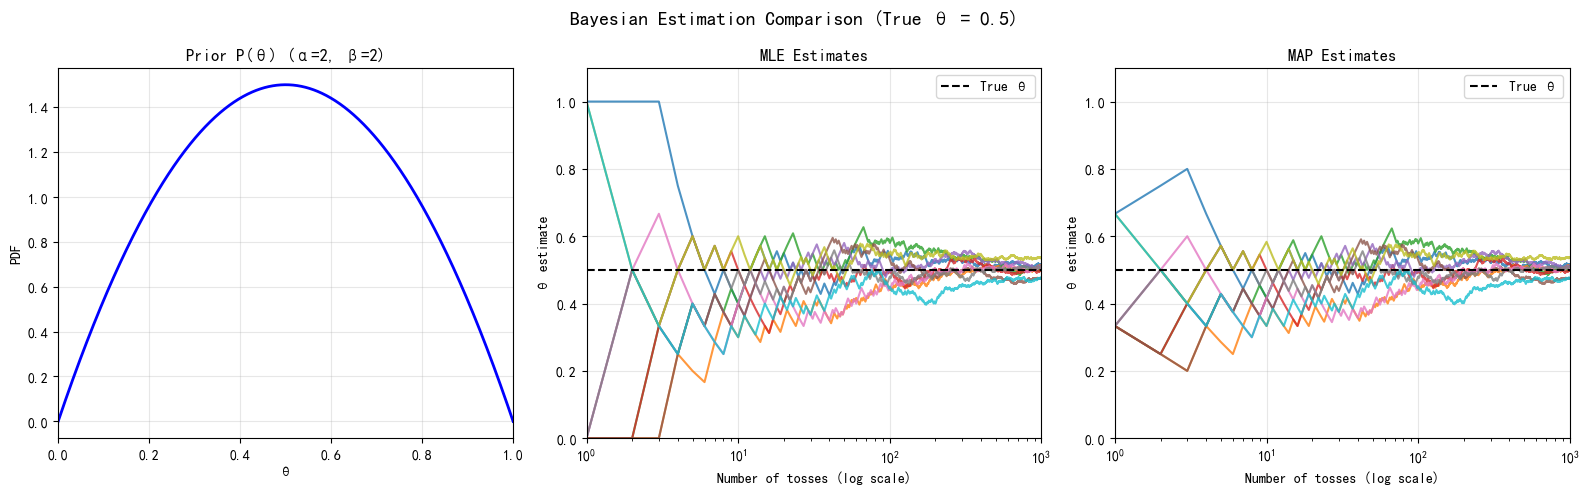

In [ ]:
#实践代码，其中数据集合就是模拟抛硬币，并对此进行分析
import numpy as np
import matplotlib.pyplot as plt
import math 
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["SimHei"],  # 黑体
    "axes.unicode_minus": False
})


true_theta=0.5
alpha_prior=2 #先验概率alpha值
beta_prior=2 #beta值
n_trials=1000 #实验次数
n_runs=10 #轨迹数

def beta_pdf(x,a,b):
    numerator=(x**(a-1)*((1-x)**(b-1)))
    denominator=(math.gamma(a)*math.gamma(b))/math.gamma(a+b)
    return numerator/denominator

def simulate_coin_tosses(true_theta,n_trials,alpha_prior,beta_prior):
    n_heads=0
    n_tails=0
    mle_list=[]#MLE
    map_list=[]#MAP
    bayes_list=[]#贝叶斯

    #扔硬币
    for t in range(1,n_trials+1):#从投硬币一次到1000次
        outcome=np.random.binomial(1,true_theta)
        if outcome==1:
            n_heads+=1
        else:
            n_tails+=1
    
        #MLE估计，有公式，当然求这个公式就是对其求对数求导数取0得到
        mle=n_heads/t
        mle_list.append(mle)

        #MAP估计，公式同样的
        map_est=(n_heads+alpha_prior-1)/(t+alpha_prior+beta_prior-2)
        map_list.append(map_est)

        #贝叶斯估计
        bayes_est=(n_heads+alpha_prior)/(t+alpha_prior+beta_prior)
        bayes_list.append(bayes_est)

    return mle_list,map_list,bayes_list


#运行多次：
mle_runs=[]
map_runs=[]
bayes_runs=[]
for _ in range(n_runs):
    mle,map_,bayes=simulate_coin_tosses(true_theta,n_trials,alpha_prior,beta_prior)
    mle_runs.append(mle)
    map_runs.append(map_)
    bayes_runs.append(bayes)

#可视化
# ---------------------- 4. 绘图 ----------------------
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Bayesian Estimation Comparison (True θ = {true_theta})', fontsize=14)

# --- 左图：先验分布 ---
x = np.linspace(0, 1, 1000)
prior_pdf = beta_pdf(x, alpha_prior, beta_prior)
ax1.plot(x, prior_pdf, 'b-', lw=2)
ax1.set_title(f'Prior P(θ) (α={alpha_prior}, β={beta_prior})')
ax1.set_xlabel('θ')
ax1.set_ylabel('PDF')
ax1.set_xlim(0, 1)
ax1.grid(True, alpha=0.3)

# --- 中图：MLE轨迹 ---
colors = plt.cm.tab10(np.arange(n_runs))
for i in range(n_runs):
    ax2.plot(range(1, n_trials+1), mle_runs[i], color=colors[i], alpha=0.8)
ax2.axhline(y=true_theta, color='k', linestyle='--', label='True θ')
ax2.set_title('MLE Estimates')
ax2.set_xlabel('Number of tosses (log scale)')
ax2.set_ylabel('θ estimate')
ax2.set_xscale('log')
ax2.set_xlim(1, n_trials)
ax2.set_ylim(0, 1.1)
ax2.grid(True, alpha=0.3)
ax2.legend()

# --- 右图：MAP轨迹 ---
for i in range(n_runs):
    ax3.plot(range(1, n_trials+1), map_runs[i], color=colors[i], alpha=0.8)
ax3.axhline(y=true_theta, color='k', linestyle='--', label='True θ')
ax3.set_title('MAP Estimates')
ax3.set_xlabel('Number of tosses (log scale)')
ax3.set_ylabel('θ estimate')
ax3.set_xscale('log')
ax3.set_xlim(1, n_trials)
ax3.set_ylim(0, 1.1)
ax3.grid(True, alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()